In [ ]:
import pandas as pd
var=pd.read_csv("QS_World_University_Rankings_2025_Top_global_universities (1).csv",encoding="latin1")


Q1. Data Loading & Inspection. Load the dataset using pandas in a Jupyter cell.Display first 5 rows.What is the shape of the dataset?List all columns and their data types.Identify missing values.


Display first 5 rows

In [46]:
var.head()

,RANK_2025,RANK_2024,Institution_Name,Location,Region,SIZE,FOCUS,RES.,STATUS,Academic_Reputation_Score,...,International_Faculty_Rank,International_Students_Score,International_Students_Rank,International_Research_Network_Score,International_Research_Network_Rank,Employment_Outcomes_Score,Employment_Outcomes_Rank,Sustainability_Score,Sustainability_Rank,Overall_Score
0,1,1,Massachusetts Institute of Technology (MIT),United States,Americas,M,CO,VH,B,100.0,...,100,86.8,143,96.0,58,100.0,8,99.0,15=,100
1,2,6,Imperial College London,United Kingdom,Europe,L,FC,VH,A,98.5,...,66,99.6,44,97.4,34,93.4,61,99.7,6,98.5
2,3,3,University of Oxford,United Kingdom,Europe,L,FC,VH,A,100.0,...,120,97.7,73,100.0,1,100.0,3,85.0,126,96.9
3,4,4,Harvard University,United States,Americas,L,FC,VH,B,100.0,...,269,69.0,215,99.6,5,100.0,1,84.4,130,96.8
4,5,2,University of Cambridge,United Kingdom,Europe,L,FC,VH,A,100.0,...,73,94.8,98,99.3,10,100.0,5,84.8,127=,96.7


Shape of the Dataset

In [47]:
var.shape

(1503, 28)

List all columns and their data types

In [48]:
var.dtypes

RANK_2025                                   str
RANK_2024                                   str
Institution_Name                            str
Location                                    str
Region                                      str
SIZE                                        str
FOCUS                                       str
RES.                                        str
STATUS                                      str
Academic_Reputation_Score               float64
Academic_Reputation_Rank                    str
Employer_Reputation_Score               float64
Employer_Reputation_Rank                    str
Faculty_Student_Score                   float64
Faculty_Student_Rank                        str
Citations_per_Faculty_Score             float64
Citations_per_Faculty_Rank                  str
International_Faculty_Score             float64
International_Faculty_Rank                  str
International_Students_Score            float64
International_Students_Rank             

Identify missing values

In [49]:
var.isnull().sum()

RANK_2025                                 0
RANK_2024                                21
Institution_Name                          0
Location                                  0
Region                                    0
SIZE                                      0
FOCUS                                     0
RES.                                      0
STATUS                                   37
Academic_Reputation_Score                 0
Academic_Reputation_Rank                  0
Employer_Reputation_Score                 0
Employer_Reputation_Rank                  0
Faculty_Student_Score                     0
Faculty_Student_Rank                      0
Citations_per_Faculty_Score               0
Citations_per_Faculty_Rank                0
International_Faculty_Score             100
International_Faculty_Rank              100
International_Students_Score             58
International_Students_Rank              58
International_Research_Network_Score      1
International_Research_Network_R

Q2. Data Cleaning. Convert ranking and score columns into numeric format (if required).Handle missing values:Drop OR Impute.Show before/after comparison.Add a markdown explaining your logic.


In [66]:
numeric_cols=['Sustainability_Rank',
'Faculty_Student_Rank',
'International_Faculty_Rank',
'Academic_Reputation_Rank',
'Employer_Reputation_Rank',
'Citations_per_Faculty_Rank',
'International_Students_Rank',
'International_Research_Network_Rank',
'Overall_Score','RANK_2025',
'Employment_Outcomes_Rank']
var[numeric_cols]=var[numeric_cols].apply(pd.to_numeric,errors="coerce")

In [51]:
var.isnull().sum()

RANK_2025                                  0
RANK_2024                                 21
Institution_Name                           0
Location                                   0
Region                                     0
SIZE                                       0
FOCUS                                      0
RES.                                       0
STATUS                                    37
Academic_Reputation_Score                  0
Academic_Reputation_Rank                 903
Employer_Reputation_Score                  0
Employer_Reputation_Rank                 903
Faculty_Student_Score                      0
Faculty_Student_Rank                     821
Citations_per_Faculty_Score                0
Citations_per_Faculty_Rank               803
International_Faculty_Score              100
International_Faculty_Rank               822
International_Students_Score              58
International_Students_Rank              814
International_Research_Network_Score       1
Internatio

In [52]:
var.dropna(inplace=True)

Ranking and score columns were converted into numeric format using `pd.to_numeric()`.
Invalid values were converted into `NaN`.
Missing values in the dataset were identified.
Missing values were filled using the average (mean) value.
Before and after comparison was done using `isnull().sum()` to check the cleaning process.

Q3. Feature Engineering (Using NumPy). Create a new column Score_Category:Elite → ≥ 90,High → 75–89,Medium → 50–74,Low → < 50. Use numpy.where() or vectorized operations.


In [53]:
import numpy as np
var["Score_Category"]=np.where(var["Overall_Score"]>=90,"Elite",
                      np.where(var["Overall_Score"]>=75,"High",
                       np.where(var["Overall_Score"]>=50,"Medium","low")))
print(var[["Overall_Score","Score_Category"]])

     Overall_Score Score_Category
1             98.5          Elite
2             96.9          Elite
3             96.8          Elite
6             93.9          Elite
9             90.9          Elite
10            90.3          Elite
11            90.1          Elite
23            84.7           High
24            84.1           High
27            83.2           High
28            83.0           High
34            82.0           High
37            81.0           High
38            80.3           High
40            80.2           High
44            77.8           High
48            77.0           High
51            76.0           High
53            75.4           High
61            70.7         Medium
63            70.3         Medium
68            68.2         Medium
73            65.7         Medium
74            65.6         Medium
77            65.0         Medium
78            64.7         Medium
79            64.1         Medium
80            64.1         Medium
88            

In [54]:
var['RANK_2024'].dtypes

<StringDtype(storage='python', na_value=nan)>

Q4. Top Universities Analysis.Find Top 10 universities by rank,Add proper labels, title, and formatting.




Text(0, 0.5, 'Rank')

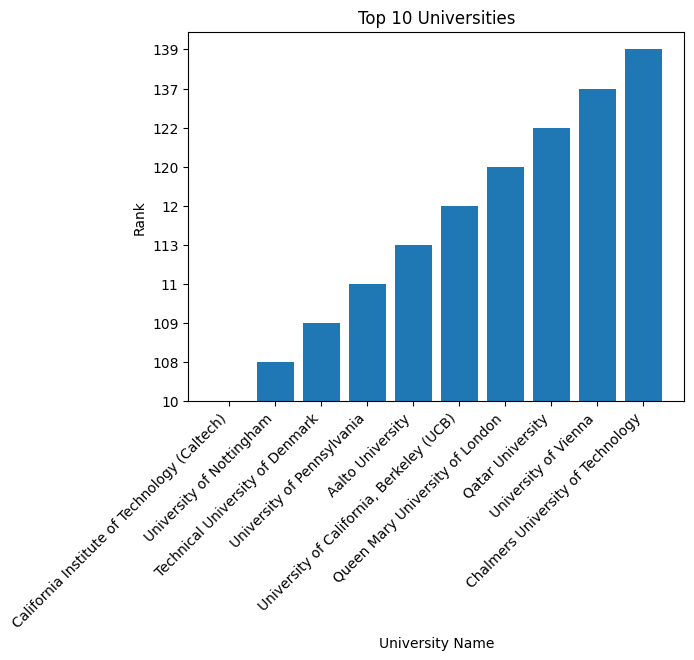

In [55]:
import matplotlib.pyplot as plt
top10=var.sort_values(by="RANK_2025").head(10)
plt.bar(top10['Institution_Name'],top10['RANK_2025'])
plt.title('Top 10 Universities')
plt.xlabel('University Name')
plt.xticks(rotation=45,ha="right")
plt.ylabel('Rank')


Insights :

1.The top 10 universities have very good rankings.

2.Universities from the USA and UK appear many times in the top rankings.

3.Higher-ranked universities usually have better academic performance and reputation.

Q5. Country-wise Dominance. Count universities per country.Display Top 10 countries.Create an interactive chart using Plotly.


In [56]:
country_count = var['Location'].value_counts()
top10_countries=country_count.head(10)
print(top10_countries)

Location
United Kingdom      13
United States        7
Canada               4
Netherlands          4
Sweden               4
China (Mainland)     3
France               2
Germany              2
Australia            2
Denmark              2
Name: count, dtype: int64


In [57]:
import plotly.express as px

px.bar(x=top10_countries.index,y=top10_countries.values)

   

Interpretation

1. Some countries have a large number of universities in the rankings.

2. The USA and UK appear among the top countries with many universities.

3. Countries with more universities usually have a stronger global education presence.

Q6. Score Distribution. Plot histogram + KDE using Seaborn. Add explanation

In [58]:
import seaborn as sns

<Axes: xlabel='Overall_Score', ylabel='Count'>

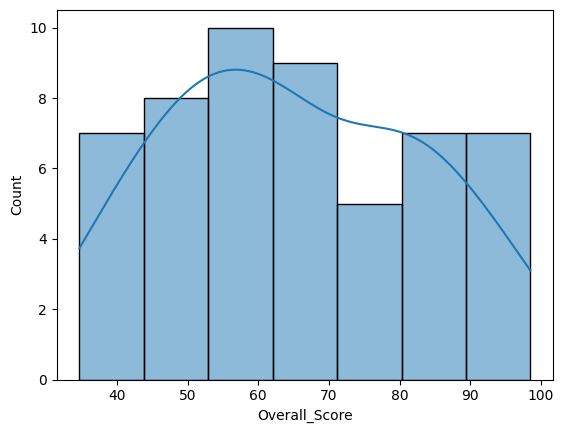

In [59]:
sns.histplot(var['Overall_Score'],kde=True)

Explanation

1. Most universities have scores in the middle range.

2. The distribution is slightly skewed because very high scores are less common.

3. Only a few universities have extremely high overall scores.

Q7. Correlation Analysis.Compute correlation matrix.Plot heatmap using seaborn.Identify strongest relationship

In [60]:
corr_matrix = var[numeric_cols].corr()
print(corr_matrix)

                                     Sustainability_Rank  \
Sustainability_Rank                             1.000000   
Faculty_Student_Rank                           -0.205667   
International_Faculty_Rank                      0.063593   
Academic_Reputation_Rank                        0.444469   
Employer_Reputation_Rank                        0.375294   
Citations_per_Faculty_Rank                     -0.022009   
International_Students_Rank                     0.076404   
International_Research_Network_Rank             0.402592   
Overall_Score                                  -0.339371   
Employment_Outcomes_Rank                        0.280941   

                                     Faculty_Student_Rank  \
Sustainability_Rank                             -0.205667   
Faculty_Student_Rank                             1.000000   
International_Faculty_Rank                      -0.043039   
Academic_Reputation_Rank                         0.196689   
Employer_Reputation_Rank          

<Axes: >

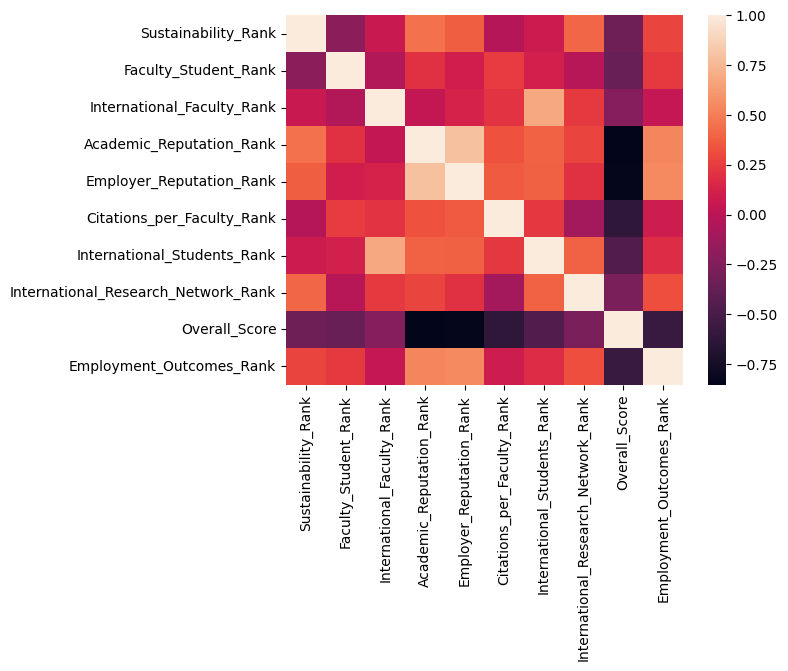

In [61]:
sns.heatmap(corr_matrix)

Strong Relationships

1. Overall Score and Academic Reputation have a strong positive relationship.

2. Universities with better academic reputation usually have higher overall scores.

3. The heatmap helps understand relationships between different university factors.

Q8. Region-wise Performance.Compute average score per region using pandas.Plot using Matplotlib.

In [62]:
region_score = var.groupby('Region')['Overall_Score'].mean()
print(region_score)

Region
Africa      35.000000
Americas    75.490909
Asia        62.600000
Europe      62.933333
Oceania     64.450000
Name: Overall_Score, dtype: float64


<BarContainer object of 5 artists>

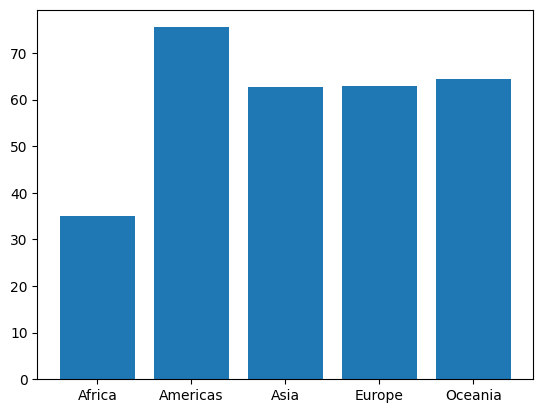

In [63]:
plt.bar(region_score.index,region_score.values)

 Interpretation

1. Some regions perform better than others in university rankings.

2. Regions with higher scores have stronger universities.

3. Regions with lower scores need improvement in education and research.

Q9. Rank vs Score Relationship.Create scatter plot using Plotly:X → Rank,Y → Score. Add trendline.Comment on relationship


In [67]:
px.scatter(var,x='RANK_2025',y='Overall_Score',trendline='ols')

Rank vs Score Relationship

1. Universities with better ranks usually have higher scores.

2. As rank number increases, the overall score decreases.

3. The scatter plot shows a negative relationship between rank and score.

Q10. Top University per Country. For each country, find the highest-ranked university.Display as a DataFrame.

In [69]:
sorted_data=var.sort_values(by="RANK_2025")
top_university=sorted_data.groupby('Location').first()
print(top_university[['Institution_Name', 'RANK_2025']])

                                                   Institution_Name  RANK_2025
Location                                                                      
Australia                              The University of Queensland         40
Austria                                        University of Vienna        137
Belgium                                            Ghent University        169
Canada                                        University of Toronto         25
China (Mainland)                                   Fudan University         39
Denmark                             Technical University of Denmark        109
Finland                                            Aalto University        113
France                                               Université PSL         24
Germany                              Technical University of Munich         28
Hong Kong SAR                          City University of Hong Kong         62
Ireland                                     Universi

Q11. Outlier Detection. Detect outliers using:IQR OR Z-score (numpy),Visualize using boxplot (seaborn). Mention number of outliers found.

Number of outliers:  0


<Axes: xlabel='Overall_Score'>

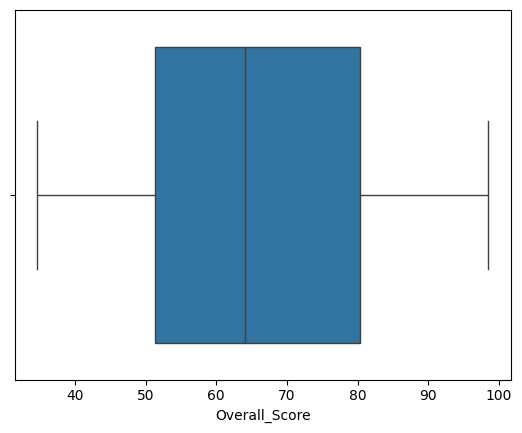

In [73]:
score=var['Overall_Score']
Q1=score.quantile(0.25)
Q3=score.quantile(0.75)
IQR=Q3-Q1
lower_limit=Q1-1.5*IQR
upper_limit=Q3+1.5*IQR
outliers=var[(score<lower_limit)|(score>upper_limit)]
print("Number of outliers: ",len(outliers))
sns.boxplot(x=var['Overall_Score'])


Q12. Score Category Analysis. Count universities in each Score_Category. Plot:Pie chart OR Bar chart. Interpret proportions.


In [74]:
category_count = var['Score_Category'].value_counts()
print(category_count)

Score_Category
Medium    22
High      12
low       12
Elite      7
Name: count, dtype: int64


Text(0, 0.5, 'Number of Universities')

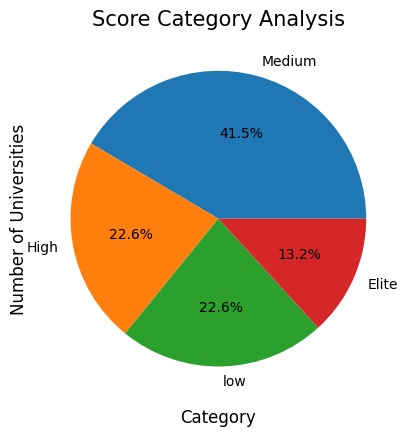

In [93]:
plt.pie(category_count.values,labels=category_count.index,autopct='%1.1f%%')
plt.title('Score Category Analysis',fontsize=15)
plt.xlabel('Category',fontsize=12)
plt.ylabel('Number of Universities',fontsize=12)

Interpretation

1. Most universities are in the Medium and Low categories.

2. Very few universities have Elite scores.

3. High scores are achieved by only a small number of universities.

Q13. Country vs Average Rank. Compute average rank per country. Which country performs best on average? Compare with number of universities.

In [92]:
avg_rank=var.groupby('Location')['RANK_2025'].mean()
avg_rank = avg_rank.sort_values()
print(avg_rank)
print("Best performing country: ",avg_rank.head(1))
university_count = var['Location'].value_counts()
print("Number of universities per country: ",university_count)

Location
Switzerland           7.000000
France               43.500000
Canada               47.000000
Hong Kong SAR        62.000000
United Kingdom       73.153846
United States        81.857143
China (Mainland)     92.000000
Australia           109.500000
Finland             113.000000
Sweden              120.500000
Qatar               122.000000
Germany             127.500000
Austria             137.000000
Netherlands         149.000000
Belgium             169.000000
Denmark             207.500000
Taiwan              215.000000
Ireland             273.000000
South Africa        312.000000
Name: RANK_2025, dtype: float64
Best performing country:  Location
Switzerland    7.0
Name: RANK_2025, dtype: float64
Number of universities per country:  Location
United Kingdom      13
United States        7
Canada               4
Netherlands          4
Sweden               4
China (Mainland)     3
France               2
Germany              2
Australia            2
Denmark              2
Ireland 

Q14. Multi-variable Visualization. Create Plotly scatter:X → Score,Y → Rank,Color → Region,Size → Score.Derive 2–3 insights.


In [94]:
px.scatter(var,x='Overall_Score',y='RANK_2025',color='Region',size='Overall_Score')


Insights

1. Universities with high scores usually have better ranks.

2. Some regions have stronger university performance than others.

3. Bigger circles in the graph show universities with higher scores.

Q15. Business Insight (Critical Thinking). Write in markdown:If you are a policymaker:What factors should universities improve?Which regions lag behind?What trends may shape future rankings?




Universities can improve their rankings by focusing on better teaching, stronger research, and more opportunities for students.  
In the future, technology, innovation, and global collaborations will play an important role in shaping university rankings.  mene ise nikala hai tum ek baar dekh lo ise